# CSIRO Biomass Regression - Training Results Analysis

This notebook analyzes the training results from the biomass regression model and presents them in a format suitable for reporting.

## Overview
- **Model**: EfficientNet-B6
- **Task**: Biomass regression (dry weight prediction)
- **Training**: 40 epochs with early stopping
- **Evaluation**: Test set performance metrics


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for publication-quality plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set figure parameters for better quality
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

print("✓ Libraries loaded successfully")


✓ Libraries loaded successfully


## Load and Preprocess Metrics Data


In [2]:
# Load metrics CSV
metrics_path = Path('metrics.csv')
if not metrics_path.exists():
    raise FileNotFoundError(f"metrics.csv not found at {metrics_path.absolute()}")

# Check file size and content
file_size = metrics_path.stat().st_size
print(f"File size: {file_size} bytes")
print(f"File path: {metrics_path.absolute()}")

# Try reading with different methods
try:
    # First, try reading normally
    df = pd.read_csv(metrics_path)
except Exception as e:
    print(f"Error reading CSV: {e}")
    # Try reading with explicit encoding
    try:
        df = pd.read_csv(metrics_path, encoding='utf-8')
    except Exception as e2:
        print(f"Error with utf-8 encoding: {e2}")
        # Try reading with latin-1 encoding (more permissive)
        try:
            df = pd.read_csv(metrics_path, encoding='latin-1')
        except Exception as e3:
            print(f"Error with latin-1 encoding: {e3}")
            # Read line by line to debug
            with open(metrics_path, 'r', encoding='utf-8') as f:
                lines = f.readlines()
                print(f"Total lines in file: {len(lines)}")
                print(f"First few lines of file:")
                for i, line in enumerate(lines[:5]):
                    print(f"  Line {i}: {repr(line[:100])}")
            raise

# Check if dataframe is empty
if df.empty:
    raise ValueError(f"CSV file appears to be empty or has no valid data")

print(f"✓ Loaded metrics data: {len(df)} rows")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()


File size: 20969 bytes
File path: /Users/ryan/Code/csiro/metrics.csv
✓ Loaded metrics data: 261 rows
Columns: ['epoch', 'step', 'test_loss', 'test_mae', 'test_mse', 'test_mse_epoch', 'test_smooth_l1', 'train_loss_epoch', 'train_loss_step', 'train_mae_epoch', 'train_mse', 'train_mse_epoch', 'train_smooth_l1', 'val_loss', 'val_mae', 'val_mse', 'val_mse_epoch', 'val_smooth_l1']

First few rows:


,epoch,step,test_loss,test_mae,test_mse,test_mse_epoch,test_smooth_l1,train_loss_epoch,train_loss_step,train_mae_epoch,train_mse,train_mse_epoch,train_smooth_l1,val_loss,val_mae,val_mse,val_mse_epoch,val_smooth_l1
0,0,9,NaN,NaN,NaN,NaN,NaN,NaN,1161.396606,NaN,1646.940430,NaN,28.460922,NaN,NaN,NaN,NaN,NaN
1,0,19,NaN,NaN,NaN,NaN,NaN,NaN,708.886902,NaN,1003.304138,NaN,21.913456,NaN,NaN,NaN,NaN,NaN
2,0,29,NaN,NaN,NaN,NaN,NaN,NaN,693.799805,NaN,982.253235,NaN,20.741806,NaN,NaN,NaN,NaN,NaN
3,0,39,NaN,NaN,NaN,NaN,NaN,NaN,780.696777,NaN,1105.188721,NaN,23.548908,NaN,NaN,NaN,NaN,NaN
4,0,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1041.806763,26.466595,1477.161499,1477.161499,25.97908


In [3]:
# Clean and process the data
# Extract epoch-level metrics (remove step-level data)
epoch_metrics = df[df['epoch'].notna()].copy()

# Group by epoch and combine train/val metrics that are on separate rows
# First, separate train and val rows
train_rows = epoch_metrics[epoch_metrics['train_loss_epoch'].notna()].copy()
val_rows = epoch_metrics[epoch_metrics['val_loss'].notna()].copy()

# Merge train and val metrics by epoch
combined_metrics = pd.merge(
    train_rows[['epoch', 'train_loss_epoch', 'train_mae_epoch', 'train_mse_epoch']],
    val_rows[['epoch', 'val_loss', 'val_mae', 'val_mse_epoch']],
    on='epoch',
    how='outer'
).sort_values('epoch').reset_index(drop=True)

# Also include test metrics separately
test_metrics = df[df['test_loss'].notna()].copy()

print(f"✓ Processed {len(combined_metrics)} epoch-level records")
print(f"✓ Found {len(test_metrics)} test evaluation records")

# Show summary
print(f"\nEpoch range: {combined_metrics['epoch'].min():.0f} to {combined_metrics['epoch'].max():.0f}")
print(f"\nSample epoch data:")
combined_metrics.head(10)


✓ Processed 40 epoch-level records
✓ Found 1 test evaluation records

Epoch range: 0 to 39

Sample epoch data:


,epoch,train_loss_epoch,train_mae_epoch,train_mse_epoch,val_loss,val_mae,val_mse_epoch
0,0,854.513733,24.034559,1210.636963,1041.806763,26.466595,1477.161499
1,1,789.905579,22.710413,1118.913208,973.808838,25.255632,1380.540771
2,2,741.470520,21.856249,1050.085938,917.338562,24.330172,1300.266968
3,3,702.657715,21.296421,994.880005,869.790710,23.622852,1232.643555
4,4,668.101257,20.825150,945.715759,815.365173,22.904860,1155.201538
5,5,642.647705,20.427271,909.523621,781.872559,22.408678,1107.568237
6,6,614.998657,20.094492,870.168091,748.909424,22.058210,1060.626465
7,7,597.884155,19.935257,845.787476,725.224060,21.740089,1026.928955
8,8,572.163086,19.601242,809.186035,701.084778,21.429605,992.577148
9,9,563.221008,19.472198,796.466675,677.953918,21.211182,959.627197


## Training Curves: Loss Over Epochs


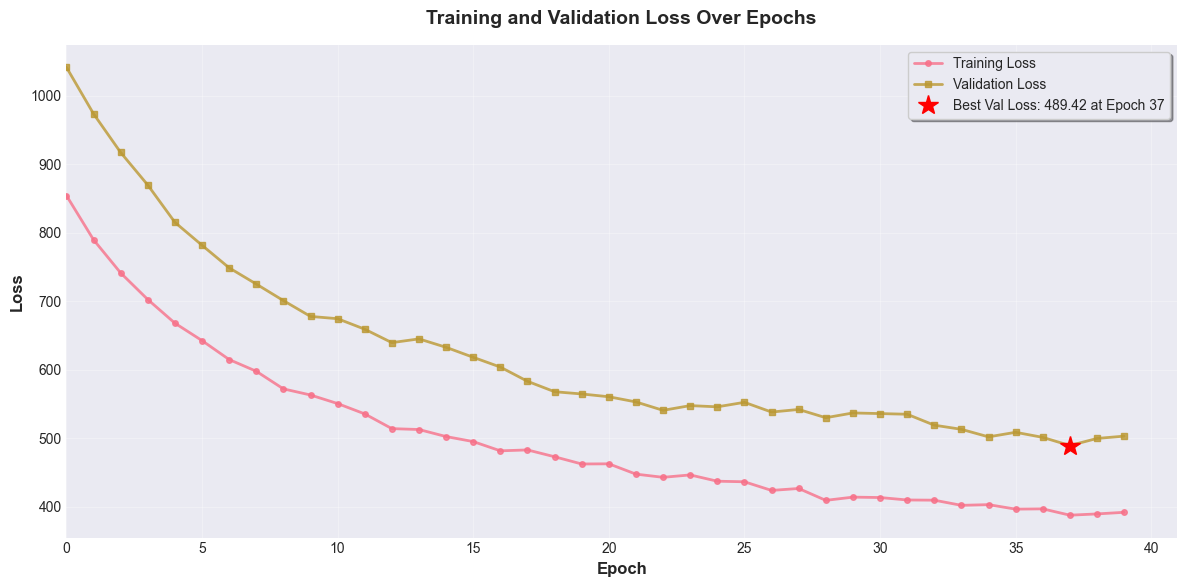

Best validation loss: 489.4179 at epoch 37
Final training loss: 391.9255
Final validation loss: 503.1570


In [4]:
# Plot training and validation loss
fig, ax = plt.subplots(figsize=(12, 6))

# Filter to rows with both train and val loss
plot_data = combined_metrics[['epoch', 'train_loss_epoch', 'val_loss']].dropna()

if len(plot_data) > 0:
    ax.plot(plot_data['epoch'], plot_data['train_loss_epoch'], 
            label='Training Loss', marker='o', linewidth=2, markersize=4, alpha=0.8)
    ax.plot(plot_data['epoch'], plot_data['val_loss'], 
            label='Validation Loss', marker='s', linewidth=2, markersize=4, alpha=0.8)

    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('Loss', fontweight='bold')
    ax.set_title('Training and Validation Loss Over Epochs', fontweight='bold', pad=15)
    ax.legend(loc='best', frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)

    # Add best validation loss marker
    if plot_data['val_loss'].notna().any():
        best_val_loss_idx = plot_data['val_loss'].idxmin()
        best_epoch = plot_data.loc[best_val_loss_idx, 'epoch']
        best_val_loss = plot_data.loc[best_val_loss_idx, 'val_loss']
        ax.plot(best_epoch, best_val_loss, 'r*', markersize=15, label=f'Best Val Loss: {best_val_loss:.2f} at Epoch {best_epoch:.0f}')
        ax.legend(loc='best', frameon=True, fancybox=True, shadow=True)
    
    plt.tight_layout()
    plt.show()

    print(f"Best validation loss: {best_val_loss:.4f} at epoch {best_epoch:.0f}")
    print(f"Final training loss: {plot_data['train_loss_epoch'].iloc[-1]:.4f}")
    print(f"Final validation loss: {plot_data['val_loss'].iloc[-1]:.4f}")
else:
    print("⚠ No data available for plotting (both train and val loss)")


## Training Curves: MAE (Mean Absolute Error) Over Epochs


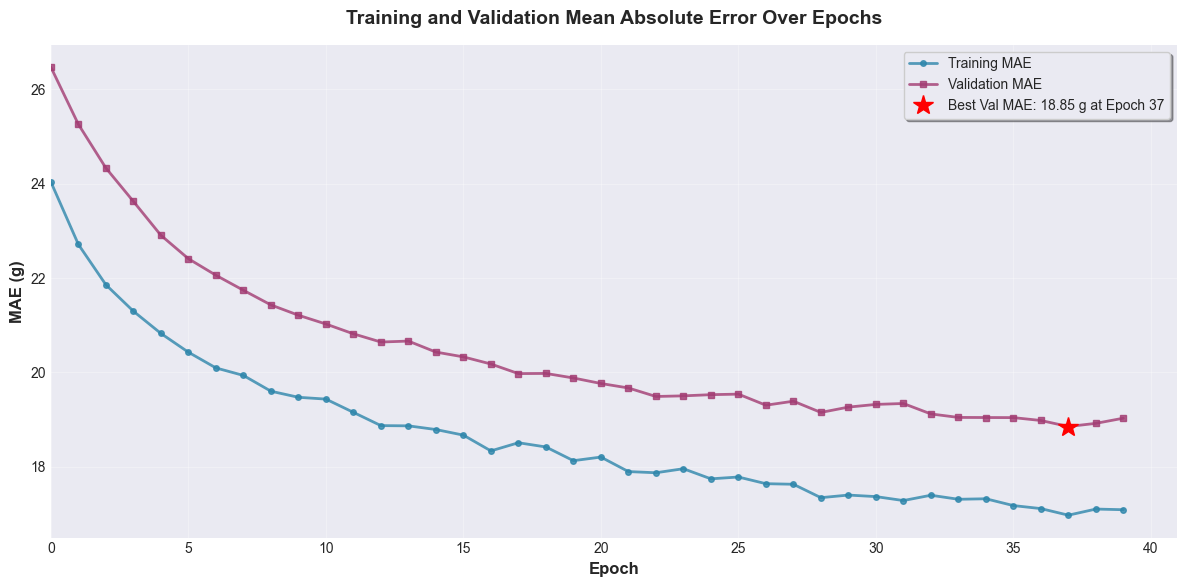

Best validation MAE: 18.8528 g at epoch 37
Final training MAE: 17.0896 g
Final validation MAE: 19.0292 g


In [5]:
# Plot training and validation MAE
fig, ax = plt.subplots(figsize=(12, 6))

plot_data = combined_metrics[['epoch', 'train_mae_epoch', 'val_mae']].dropna()

if len(plot_data) > 0:
    ax.plot(plot_data['epoch'], plot_data['train_mae_epoch'], 
            label='Training MAE', marker='o', linewidth=2, markersize=4, alpha=0.8, color='#2E86AB')
    ax.plot(plot_data['epoch'], plot_data['val_mae'], 
            label='Validation MAE', marker='s', linewidth=2, markersize=4, alpha=0.8, color='#A23B72')

    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('MAE (g)', fontweight='bold')
    ax.set_title('Training and Validation Mean Absolute Error Over Epochs', fontweight='bold', pad=15)
    ax.legend(loc='best', frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)

    # Add best validation MAE marker
    if plot_data['val_mae'].notna().any():
        best_val_mae_idx = plot_data['val_mae'].idxmin()
        best_epoch = plot_data.loc[best_val_mae_idx, 'epoch']
        best_val_mae = plot_data.loc[best_val_mae_idx, 'val_mae']
        ax.plot(best_epoch, best_val_mae, 'r*', markersize=15, label=f'Best Val MAE: {best_val_mae:.2f} g at Epoch {best_epoch:.0f}')
        ax.legend(loc='best', frameon=True, fancybox=True, shadow=True)
    
    plt.tight_layout()
    plt.show()

    print(f"Best validation MAE: {best_val_mae:.4f} g at epoch {best_epoch:.0f}")
    print(f"Final training MAE: {plot_data['train_mae_epoch'].iloc[-1]:.4f} g")
    print(f"Final validation MAE: {plot_data['val_mae'].iloc[-1]:.4f} g")
else:
    print("⚠ No data available for plotting (both train and val MAE)")


## Training Curves: MSE (Mean Squared Error) Over Epochs


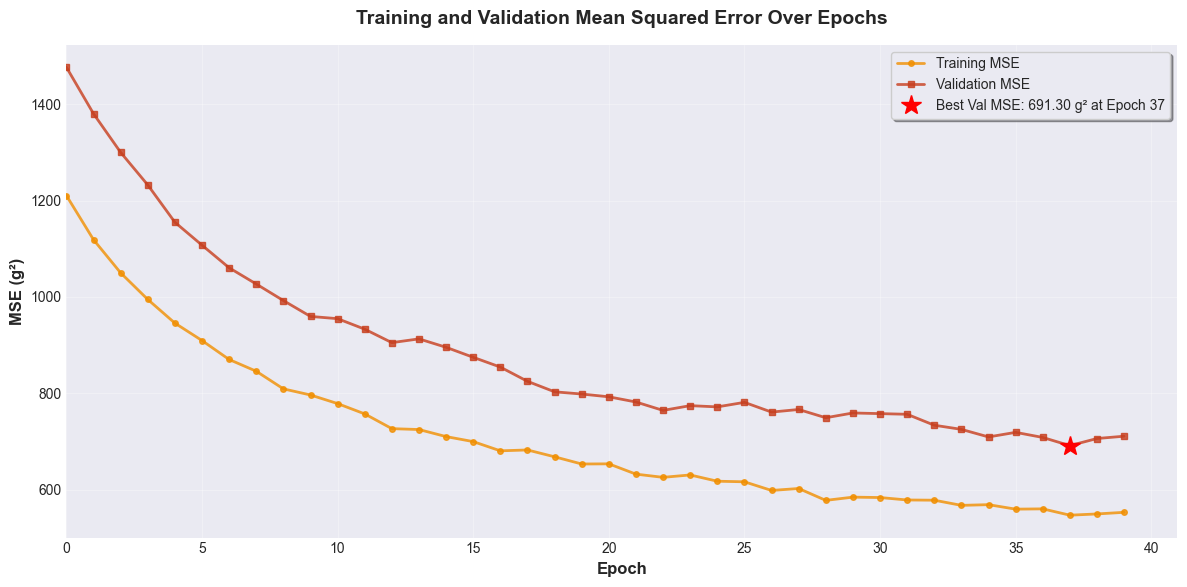

Best validation MSE: 691.3017 g² at epoch 37
Final training MSE: 552.7812 g²
Final validation MSE: 710.8527 g²


In [6]:
# Plot training and validation MSE
fig, ax = plt.subplots(figsize=(12, 6))

plot_data = combined_metrics[['epoch', 'train_mse_epoch', 'val_mse_epoch']].dropna()

if len(plot_data) > 0:
    ax.plot(plot_data['epoch'], plot_data['train_mse_epoch'], 
            label='Training MSE', marker='o', linewidth=2, markersize=4, alpha=0.8, color='#F18F01')
    ax.plot(plot_data['epoch'], plot_data['val_mse_epoch'], 
            label='Validation MSE', marker='s', linewidth=2, markersize=4, alpha=0.8, color='#C73E1D')

    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('MSE (g²)', fontweight='bold')
    ax.set_title('Training and Validation Mean Squared Error Over Epochs', fontweight='bold', pad=15)
    ax.legend(loc='best', frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)

    # Add best validation MSE marker
    if plot_data['val_mse_epoch'].notna().any():
        best_val_mse_idx = plot_data['val_mse_epoch'].idxmin()
        best_epoch = plot_data.loc[best_val_mse_idx, 'epoch']
        best_val_mse = plot_data.loc[best_val_mse_idx, 'val_mse_epoch']
        ax.plot(best_epoch, best_val_mse, 'r*', markersize=15, label=f'Best Val MSE: {best_val_mse:.2f} g² at Epoch {best_epoch:.0f}')
        ax.legend(loc='best', frameon=True, fancybox=True, shadow=True)
    
    plt.tight_layout()
    plt.show()

    print(f"Best validation MSE: {best_val_mse:.4f} g² at epoch {best_epoch:.0f}")
    print(f"Final training MSE: {plot_data['train_mse_epoch'].iloc[-1]:.4f} g²")
    print(f"Final validation MSE: {plot_data['val_mse_epoch'].iloc[-1]:.4f} g²")
else:
    print("⚠ No data available for plotting (both train and val MSE)")


## Combined Metrics Overview


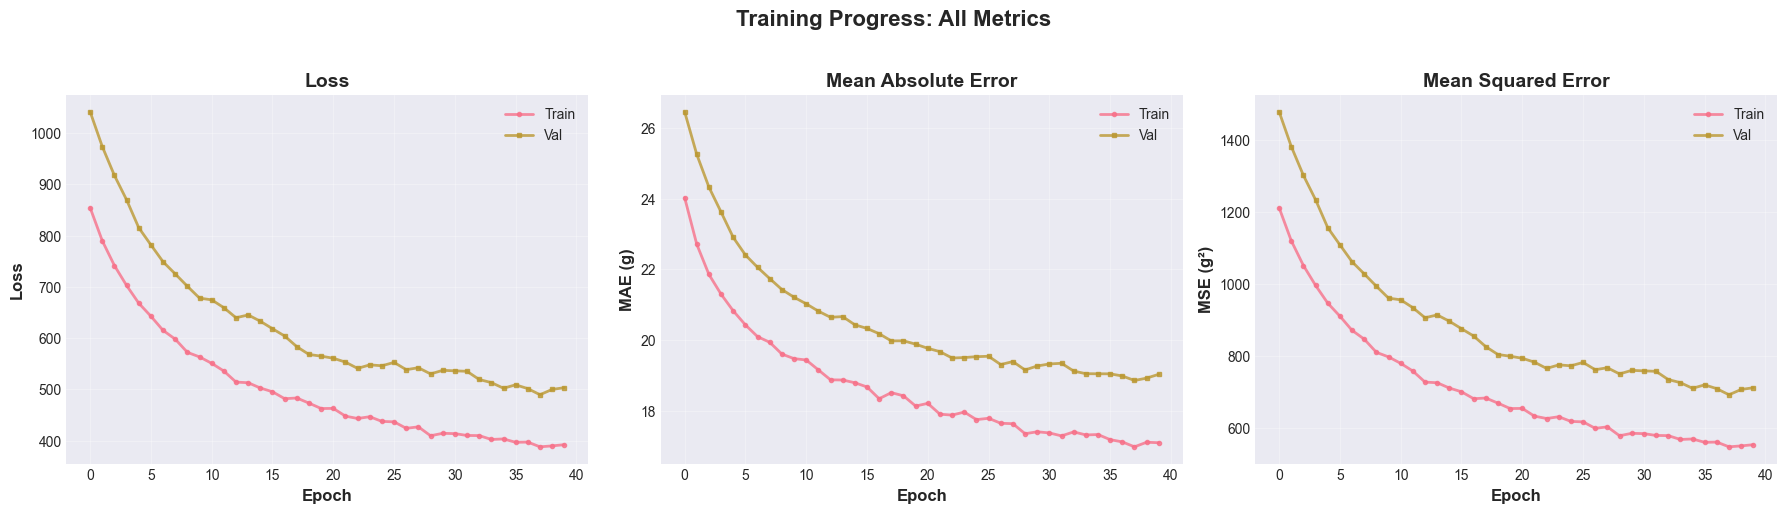

In [7]:
# Create a combined plot with all metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
ax1 = axes[0]
plot_data = combined_metrics[['epoch', 'train_loss_epoch', 'val_loss']].dropna()
if len(plot_data) > 0:
    ax1.plot(plot_data['epoch'], plot_data['train_loss_epoch'], 
             label='Train', marker='o', linewidth=2, markersize=3, alpha=0.8)
    ax1.plot(plot_data['epoch'], plot_data['val_loss'], 
             label='Val', marker='s', linewidth=2, markersize=3, alpha=0.8)
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Loss', fontweight='bold')
ax1.set_title('Loss', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# MAE
ax2 = axes[1]
plot_data = combined_metrics[['epoch', 'train_mae_epoch', 'val_mae']].dropna()
if len(plot_data) > 0:
    ax2.plot(plot_data['epoch'], plot_data['train_mae_epoch'], 
             label='Train', marker='o', linewidth=2, markersize=3, alpha=0.8)
    ax2.plot(plot_data['epoch'], plot_data['val_mae'], 
             label='Val', marker='s', linewidth=2, markersize=3, alpha=0.8)
ax2.set_xlabel('Epoch', fontweight='bold')
ax2.set_ylabel('MAE (g)', fontweight='bold')
ax2.set_title('Mean Absolute Error', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# MSE
ax3 = axes[2]
plot_data = combined_metrics[['epoch', 'train_mse_epoch', 'val_mse_epoch']].dropna()
if len(plot_data) > 0:
    ax3.plot(plot_data['epoch'], plot_data['train_mse_epoch'], 
             label='Train', marker='o', linewidth=2, markersize=3, alpha=0.8)
    ax3.plot(plot_data['epoch'], plot_data['val_mse_epoch'], 
             label='Val', marker='s', linewidth=2, markersize=3, alpha=0.8)
ax3.set_xlabel('Epoch', fontweight='bold')
ax3.set_ylabel('MSE (g²)', fontweight='bold')
ax3.set_title('Mean Squared Error', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle('Training Progress: All Metrics', fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## Final Test Set Performance


FINAL TEST SET PERFORMANCE

Test Loss:     420.7494
Test MAE:      17.6645 g
Test MSE:      593.7108 g²
Test RMSE:     24.3662 g
Test SmoothL1: 17.1729

Test Set Metrics Summary:
        Metric      Value
          Loss 420.749359
       MAE (g)  17.664516
      MSE (g²) 593.710754
      RMSE (g)  24.366181
Smooth L1 Loss  17.172853


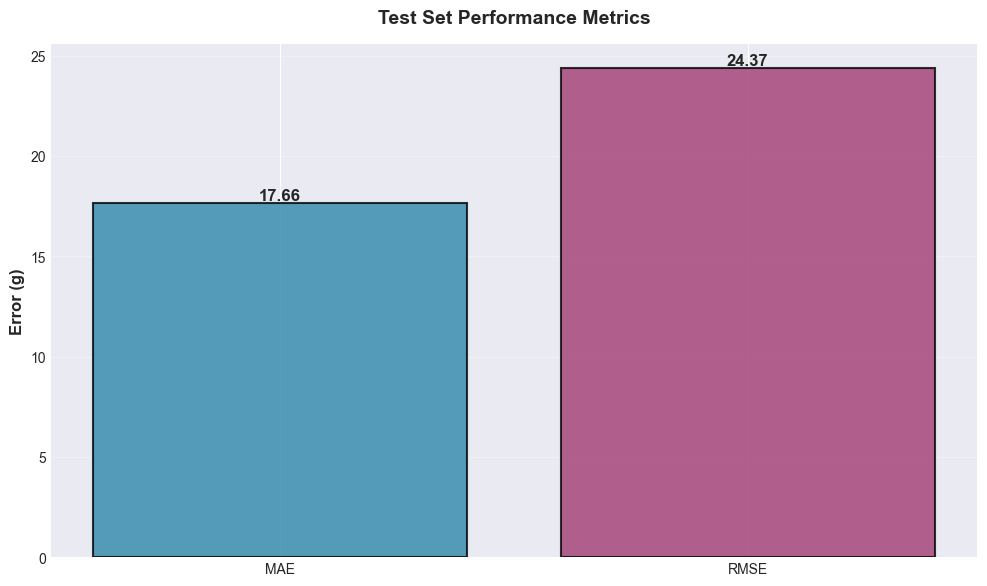

In [8]:
# Extract and display test metrics
if len(test_metrics) > 0:
    test_row = test_metrics.iloc[-1]  # Get the last test evaluation
    
    print("="*70)
    print("FINAL TEST SET PERFORMANCE")
    print("="*70)
    print(f"\nTest Loss:     {test_row['test_loss']:.4f}")
    print(f"Test MAE:      {test_row['test_mae']:.4f} g")
    print(f"Test MSE:      {test_row['test_mse']:.4f} g²")
    print(f"Test RMSE:     {np.sqrt(test_row['test_mse']):.4f} g")
    print(f"Test SmoothL1: {test_row['test_smooth_l1']:.4f}")
    print("="*70)
    
    # Create a summary table
    test_summary = pd.DataFrame({
        'Metric': ['Loss', 'MAE (g)', 'MSE (g²)', 'RMSE (g)', 'Smooth L1 Loss'],
        'Value': [
            test_row['test_loss'],
            test_row['test_mae'],
            test_row['test_mse'],
            np.sqrt(test_row['test_mse']),
            test_row['test_smooth_l1']
        ]
    })
    
    print("\nTest Set Metrics Summary:")
    print(test_summary.to_string(index=False))
    
    # Visualize test metrics
    fig, ax = plt.subplots(figsize=(10, 6))
    metrics_to_plot = ['MAE', 'RMSE']
    values_to_plot = [
        test_row['test_mae'],
        np.sqrt(test_row['test_mse'])
    ]
    
    bars = ax.bar(metrics_to_plot, values_to_plot, color=['#2E86AB', '#A23B72'], alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Error (g)', fontweight='bold')
    ax.set_title('Test Set Performance Metrics', fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars, values_to_plot):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}',
                ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("⚠ No test metrics found in the CSV file")


## Training vs Validation Comparison


Final Epoch Comparison: Training vs Validation
  Metric   Training  Validation  Difference  Difference (%)
    Loss 391.925476  503.156952  111.231476           28.38
 MAE (g)  17.089613   19.029230    1.939617           11.35
MSE (g²) 552.781189  710.852722  158.071533           28.60
RMSE (g)  23.511299   26.661821    3.150522           13.40


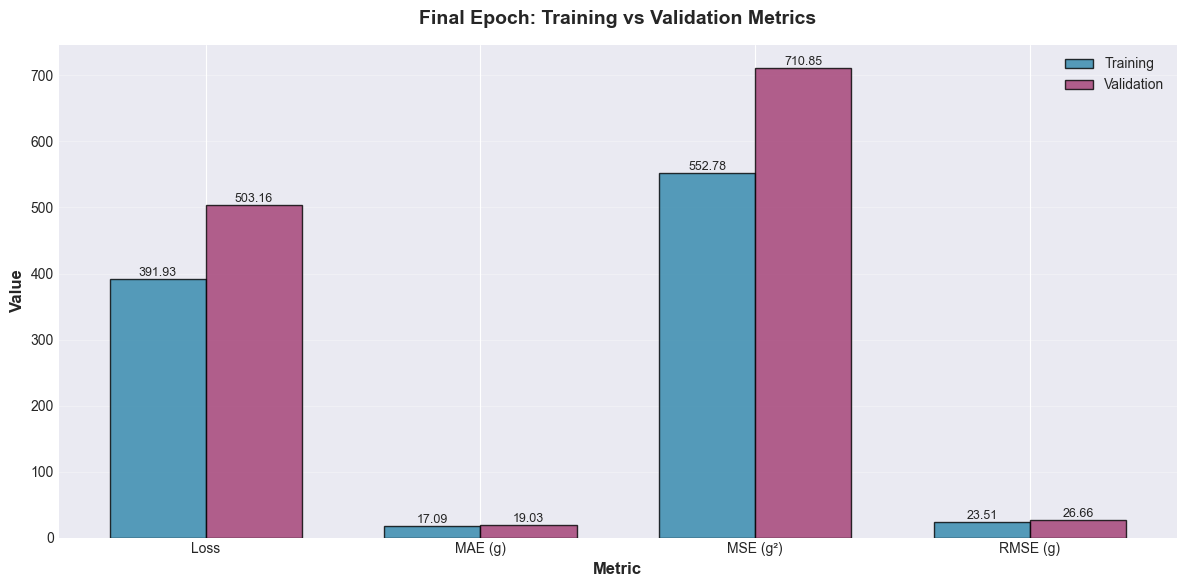

In [9]:
# Compare final training vs validation metrics
final_epoch_data = combined_metrics[combined_metrics['epoch'] == combined_metrics['epoch'].max()].iloc[0]

comparison = pd.DataFrame({
    'Metric': ['Loss', 'MAE (g)', 'MSE (g²)', 'RMSE (g)'],
    'Training': [
        final_epoch_data['train_loss_epoch'],
        final_epoch_data['train_mae_epoch'],
        final_epoch_data['train_mse_epoch'],
        np.sqrt(final_epoch_data['train_mse_epoch']) if pd.notna(final_epoch_data['train_mse_epoch']) else np.nan
    ],
    'Validation': [
        final_epoch_data['val_loss'],
        final_epoch_data['val_mae'],
        final_epoch_data['val_mse_epoch'],
        np.sqrt(final_epoch_data['val_mse_epoch']) if pd.notna(final_epoch_data['val_mse_epoch']) else np.nan
    ]
})

comparison['Difference'] = comparison['Validation'] - comparison['Training']
comparison['Difference (%)'] = ((comparison['Validation'] - comparison['Training']) / comparison['Training'] * 100).round(2)

print("Final Epoch Comparison: Training vs Validation")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)

# Visualize comparison (only for metrics that have values)
comparison_plot = comparison.dropna(subset=['Training', 'Validation'])
if len(comparison_plot) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(comparison_plot['Metric']))
    width = 0.35

    bars1 = ax.bar(x - width/2, comparison_plot['Training'], width, label='Training', 
                   color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=1)
    bars2 = ax.bar(x + width/2, comparison_plot['Validation'], width, label='Validation', 
                   color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1)

    ax.set_xlabel('Metric', fontweight='bold')
    ax.set_ylabel('Value', fontweight='bold')
    ax.set_title('Final Epoch: Training vs Validation Metrics', fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_plot['Metric'])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}',
                    ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


## Convergence Analysis


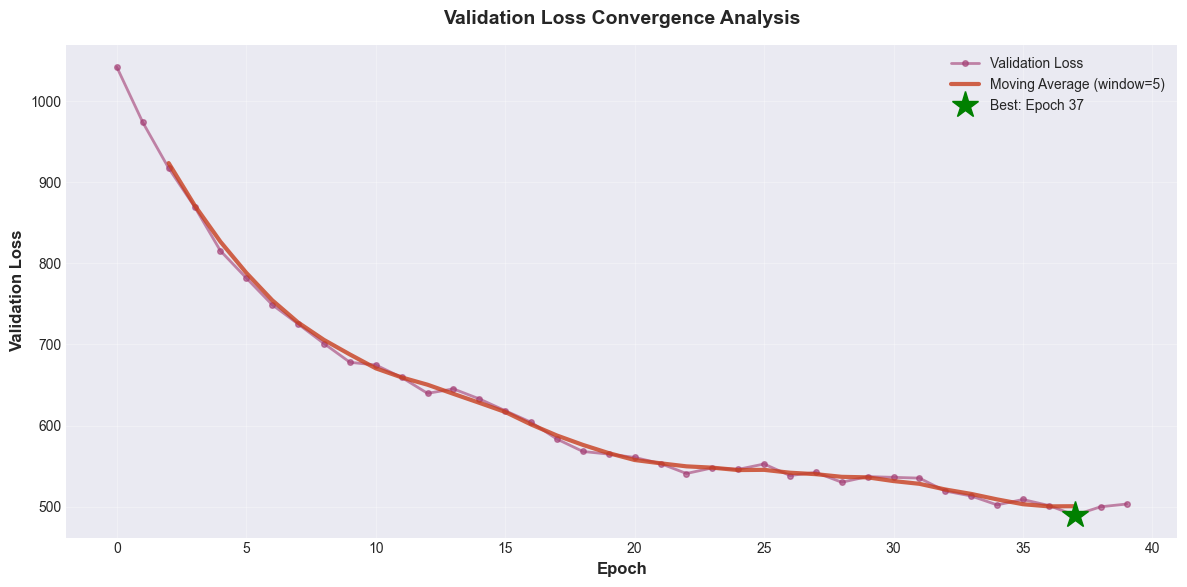

Best validation loss at epoch 37
Loss change over last 5 epochs: -5.6102 (improving)
Total epochs trained: 40


In [10]:
# Analyze convergence - check if validation loss is still improving
plot_data = combined_metrics[['epoch', 'val_loss']].dropna()
if len(plot_data) > 10:
    # Calculate moving average to smooth out noise
    window = min(5, len(plot_data) // 4)
    plot_data = plot_data.copy()
    plot_data['val_loss_ma'] = plot_data['val_loss'].rolling(window=window, center=True).mean()
    
    # Find the epoch with best validation loss
    best_idx = plot_data['val_loss'].idxmin()
    best_epoch = plot_data.loc[best_idx, 'epoch']
    
    # Check last 5 epochs for improvement
    last_5_epochs = plot_data.tail(5)
    improvement = (last_5_epochs['val_loss'].iloc[-1] - last_5_epochs['val_loss'].iloc[0])
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(plot_data['epoch'], plot_data['val_loss'], 
            label='Validation Loss', marker='o', linewidth=2, markersize=4, alpha=0.6, color='#A23B72')
    ax.plot(plot_data['epoch'], plot_data['val_loss_ma'], 
            label=f'Moving Average (window={window})', linewidth=3, alpha=0.8, color='#C73E1D')
    
    # Mark best epoch
    ax.plot(best_epoch, plot_data.loc[best_idx, 'val_loss'], 
            'g*', markersize=20, label=f'Best: Epoch {best_epoch:.0f}')
    
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('Validation Loss', fontweight='bold')
    ax.set_title('Validation Loss Convergence Analysis', fontweight='bold', pad=15)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Best validation loss at epoch {best_epoch:.0f}")
    print(f"Loss change over last 5 epochs: {improvement:.4f} ({'improving' if improvement < 0 else 'worsening'})")
    print(f"Total epochs trained: {len(plot_data)}")
else:
    print("Not enough data for convergence analysis")


## Summary Statistics


In [11]:
# Create comprehensive summary statistics
print("="*80)
print("TRAINING SUMMARY STATISTICS")
print("="*80)

# Training metrics summary
train_data = combined_metrics[['epoch', 'train_loss_epoch', 'train_mae_epoch', 'train_mse_epoch']].dropna()
val_data = combined_metrics[['epoch', 'val_loss', 'val_mae', 'val_mse_epoch']].dropna()

summary_stats = pd.DataFrame({
    'Metric': [
        'Training Loss (Initial)', 'Training Loss (Final)', 'Training Loss (Best)',
        'Training MAE (Initial)', 'Training MAE (Final)', 'Training MAE (Best)',
        'Training MSE (Initial)', 'Training MSE (Final)', 'Training MSE (Best)',
        'Validation Loss (Initial)', 'Validation Loss (Final)', 'Validation Loss (Best)',
        'Validation MAE (Initial)', 'Validation MAE (Final)', 'Validation MAE (Best)',
        'Validation MSE (Initial)', 'Validation MSE (Final)', 'Validation MSE (Best)',
    ],
    'Value': [
        train_data['train_loss_epoch'].iloc[0] if len(train_data) > 0 else np.nan,
        train_data['train_loss_epoch'].iloc[-1] if len(train_data) > 0 else np.nan,
        train_data['train_loss_epoch'].min() if len(train_data) > 0 else np.nan,
        train_data['train_mae_epoch'].iloc[0] if len(train_data) > 0 else np.nan,
        train_data['train_mae_epoch'].iloc[-1] if len(train_data) > 0 else np.nan,
        train_data['train_mae_epoch'].min() if len(train_data) > 0 else np.nan,
        train_data['train_mse_epoch'].iloc[0] if len(train_data) > 0 else np.nan,
        train_data['train_mse_epoch'].iloc[-1] if len(train_data) > 0 else np.nan,
        train_data['train_mse_epoch'].min() if len(train_data) > 0 else np.nan,
        val_data['val_loss'].iloc[0] if len(val_data) > 0 else np.nan,
        val_data['val_loss'].iloc[-1] if len(val_data) > 0 else np.nan,
        val_data['val_loss'].min() if len(val_data) > 0 else np.nan,
        val_data['val_mae'].iloc[0] if len(val_data) > 0 else np.nan,
        val_data['val_mae'].iloc[-1] if len(val_data) > 0 else np.nan,
        val_data['val_mae'].min() if len(val_data) > 0 else np.nan,
        val_data['val_mse_epoch'].iloc[0] if len(val_data) > 0 else np.nan,
        val_data['val_mse_epoch'].iloc[-1] if len(val_data) > 0 else np.nan,
        val_data['val_mse_epoch'].min() if len(val_data) > 0 else np.nan,
    ]
})

print("\nTraining Metrics:")
print(summary_stats[summary_stats['Metric'].str.contains('Training')].to_string(index=False))

print("\nValidation Metrics:")
print(summary_stats[summary_stats['Metric'].str.contains('Validation')].to_string(index=False))

# Calculate improvements
print("\n" + "="*80)
print("IMPROVEMENTS DURING TRAINING")
print("="*80)

if len(train_data) > 0 and len(val_data) > 0:
    improvements = pd.DataFrame({
        'Metric': ['Loss', 'MAE', 'MSE'],
        'Training Improvement': [
            ((train_data['train_loss_epoch'].iloc[0] - train_data['train_loss_epoch'].iloc[-1]) / train_data['train_loss_epoch'].iloc[0] * 100) if train_data['train_loss_epoch'].iloc[0] > 0 else np.nan,
            ((train_data['train_mae_epoch'].iloc[0] - train_data['train_mae_epoch'].iloc[-1]) / train_data['train_mae_epoch'].iloc[0] * 100) if train_data['train_mae_epoch'].iloc[0] > 0 else np.nan,
            ((train_data['train_mse_epoch'].iloc[0] - train_data['train_mse_epoch'].iloc[-1]) / train_data['train_mse_epoch'].iloc[0] * 100) if train_data['train_mse_epoch'].iloc[0] > 0 else np.nan,
        ],
        'Validation Improvement': [
            ((val_data['val_loss'].iloc[0] - val_data['val_loss'].iloc[-1]) / val_data['val_loss'].iloc[0] * 100) if val_data['val_loss'].iloc[0] > 0 else np.nan,
            ((val_data['val_mae'].iloc[0] - val_data['val_mae'].iloc[-1]) / val_data['val_mae'].iloc[0] * 100) if val_data['val_mae'].iloc[0] > 0 else np.nan,
            ((val_data['val_mse_epoch'].iloc[0] - val_data['val_mse_epoch'].iloc[-1]) / val_data['val_mse_epoch'].iloc[0] * 100) if val_data['val_mse_epoch'].iloc[0] > 0 else np.nan,
        ]
    })

    improvements['Training Improvement'] = improvements['Training Improvement'].round(2)
    improvements['Validation Improvement'] = improvements['Validation Improvement'].round(2)

    print(improvements.to_string(index=False))
else:
    print("Insufficient data to calculate improvements")
print("="*80)


TRAINING SUMMARY STATISTICS

Training Metrics:
                 Metric       Value
Training Loss (Initial)  854.513733
  Training Loss (Final)  391.925476
   Training Loss (Best)  387.728912
 Training MAE (Initial)   24.034559
   Training MAE (Final)   17.089613
    Training MAE (Best)   16.973785
 Training MSE (Initial) 1210.636963
   Training MSE (Final)  552.781189
    Training MSE (Best)  546.835144

Validation Metrics:
                   Metric       Value
Validation Loss (Initial) 1041.806763
  Validation Loss (Final)  503.156952
   Validation Loss (Best)  489.417877
 Validation MAE (Initial)   26.466595
   Validation MAE (Final)   19.029230
    Validation MAE (Best)   18.852823
 Validation MSE (Initial) 1477.161499
   Validation MSE (Final)  710.852722
    Validation MSE (Best)  691.301697

IMPROVEMENTS DURING TRAINING
Metric  Training Improvement  Validation Improvement
  Loss                 54.13                   51.70
   MAE                 28.90                   28.10
   

## Export Summary for Report

The following cell creates a summary CSV file that can be used in our report.


In [12]:
# Create a summary report DataFrame
report_summary = []

# Best validation metrics
best_val_loss_idx = combined_metrics['val_loss'].idxmin() if combined_metrics['val_loss'].notna().any() else None
best_val_mae_idx = combined_metrics['val_mae'].idxmin() if combined_metrics['val_mae'].notna().any() else None
best_val_mse_idx = combined_metrics['val_mse_epoch'].idxmin() if combined_metrics['val_mse_epoch'].notna().any() else None

# Final training metrics
final_train = combined_metrics[combined_metrics['epoch'] == combined_metrics['epoch'].max()].iloc[0]

# Test metrics
if len(test_metrics) > 0:
    test_row = test_metrics.iloc[-1]
    test_mae = test_row['test_mae']
    test_mse = test_row['test_mse']
    test_rmse = np.sqrt(test_mse)
else:
    test_mae = test_mse = test_rmse = None

report_data = {
    'Metric': [
        'Best Validation Loss', 'Best Validation MAE (g)', 'Best Validation MSE (g²)', 'Best Validation RMSE (g)',
        'Final Training Loss', 'Final Training MAE (g)', 'Final Training MSE (g²)', 'Final Training RMSE (g)',
        'Final Validation Loss', 'Final Validation MAE (g)', 'Final Validation MSE (g²)', 'Final Validation RMSE (g)',
        'Test Loss', 'Test MAE (g)', 'Test MSE (g²)', 'Test RMSE (g)',
        'Total Epochs', 'Best Val Loss Epoch', 'Best Val MAE Epoch', 'Best Val MSE Epoch'
    ],
    'Value': [
        combined_metrics.loc[best_val_loss_idx, 'val_loss'] if best_val_loss_idx is not None else None,
        combined_metrics.loc[best_val_mae_idx, 'val_mae'] if best_val_mae_idx is not None else None,
        combined_metrics.loc[best_val_mse_idx, 'val_mse_epoch'] if best_val_mse_idx is not None else None,
        np.sqrt(combined_metrics.loc[best_val_mse_idx, 'val_mse_epoch']) if best_val_mse_idx is not None and pd.notna(combined_metrics.loc[best_val_mse_idx, 'val_mse_epoch']) else None,
        final_train['train_loss_epoch'] if pd.notna(final_train['train_loss_epoch']) else None,
        final_train['train_mae_epoch'] if pd.notna(final_train['train_mae_epoch']) else None,
        final_train['train_mse_epoch'] if pd.notna(final_train['train_mse_epoch']) else None,
        np.sqrt(final_train['train_mse_epoch']) if pd.notna(final_train['train_mse_epoch']) else None,
        final_train['val_loss'] if pd.notna(final_train['val_loss']) else None,
        final_train['val_mae'] if pd.notna(final_train['val_mae']) else None,
        final_train['val_mse_epoch'] if pd.notna(final_train['val_mse_epoch']) else None,
        np.sqrt(final_train['val_mse_epoch']) if pd.notna(final_train['val_mse_epoch']) else None,
        test_row['test_loss'] if len(test_metrics) > 0 else None,
        test_mae,
        test_mse,
        test_rmse,
        combined_metrics['epoch'].max(),
        combined_metrics.loc[best_val_loss_idx, 'epoch'] if best_val_loss_idx is not None else None,
        combined_metrics.loc[best_val_mae_idx, 'epoch'] if best_val_mae_idx is not None else None,
        combined_metrics.loc[best_val_mse_idx, 'epoch'] if best_val_mse_idx is not None else None,
    ]
}

report_df = pd.DataFrame(report_data)
report_df['Value'] = report_df['Value'].round(4)

# Save to CSV
report_df.to_csv('training_summary_report.csv', index=False)
print("✓ Summary report saved to 'training_summary_report.csv'")
print("\nReport Summary:")
print(report_df.to_string(index=False))


✓ Summary report saved to 'training_summary_report.csv'

Report Summary:
                   Metric    Value
     Best Validation Loss 489.4179
  Best Validation MAE (g)  18.8528
 Best Validation MSE (g²) 691.3017
 Best Validation RMSE (g)  26.2926
      Final Training Loss 391.9255
   Final Training MAE (g)  17.0896
  Final Training MSE (g²) 552.7812
  Final Training RMSE (g)  23.5113
    Final Validation Loss 503.1570
 Final Validation MAE (g)  19.0292
Final Validation MSE (g²) 710.8527
Final Validation RMSE (g)  26.6618
                Test Loss 420.7494
             Test MAE (g)  17.6645
            Test MSE (g²) 593.7108
            Test RMSE (g)  24.3662
             Total Epochs  39.0000
      Best Val Loss Epoch  37.0000
       Best Val MAE Epoch  37.0000
       Best Val MSE Epoch  37.0000
